#  05. TF-IDF 감성 분류 & 키워드 추출

## 목적
전처리된 리뷰 텍스트를 TF-IDF로 벡터화하고, Logistic Regression으로 감성 분류기를 학습한다.
분류기의 계수를 이용해 긍정/부정을 가르는 핵심 키워드를 추출한다.

## 분석 순서
1. 라이브러리 & 데이터 로드
2. TF-IDF 벡터화
3. 감성 분류기 학습 (Logistic Regression)
4. 긍정/부정 핵심 키워드 추출
5. 영어 vs 한국어 키워드 비교
6. 시각화
7. 결과 저장

## 참고
- 이 노트북은 voted_up 기반 **이진 분류**만 다룸
- 세부 감정(기쁨, 실망, 분노 등) 분류는 LLM 기반 분석 단계에서 진행

---
## 1. 라이브러리 & 데이터 로드

In [1]:
import sqlite3
import pandas as pd
import numpy as np

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, f1_score

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'AppleGothic'
matplotlib.rcParams['axes.unicode_minus'] = False

DB_PATH = '../data/dave_diver.db'
conn = sqlite3.connect(DB_PATH)

print('라이브러리 로드 완료')

라이브러리 로드 완료


In [2]:
# ── 영어 리뷰 로드 ──
df_en = pd.read_sql("""
    SELECT review_id, voted_up, review_month, play_segment,
           playtime_at_review, playtime_hours,
           review_text, cleaned_text
    FROM cleaned_reviews_en
    WHERE cleaned_text IS NOT NULL AND cleaned_text != ''
""", conn)

# ── 한국어 리뷰 로드 ──
df_ko = pd.read_sql("""
    SELECT review_id, voted_up, review_month, play_segment,
           playtime_at_review, playtime_hours,
           review_text, cleaned_text
    FROM cleaned_reviews_ko
    WHERE cleaned_text IS NOT NULL AND cleaned_text != ''
""", conn)

for name, df in [('영어', df_en), ('한국어', df_ko)]:
    n_pos = df['voted_up'].sum()
    n_neg = len(df) - n_pos
    print(f'{name}: {len(df):,}건 (긍정 {n_pos:,} / 부정 {n_neg:,} | 긍정률 {n_pos/len(df)*100:.1f}%)')

영어: 44,839건 (긍정 43,190 / 부정 1,649 | 긍정률 96.3%)
한국어: 10,074건 (긍정 9,776 / 부정 298 | 긍정률 97.0%)


---
## 2. TF-IDF 벡터화

**TF-IDF = TF(단어 빈도) × IDF(역문서 빈도)**

단순 빈도 분석(03, 04편)에서는 모든 문서에서 흔한 단어가 상위를 차지했다.
TF-IDF는 **특정 문서에서만 자주 등장하는 단어**에 높은 가중치를 부여한다.

- TF : 특정문서에서 특정 단어가 나타는 빈도
- TF(t, d) = 단어 t가 문서 d에 등장한 횟수 / 문서 d의 전체 단어 수

- IDF : 모든 문서에서 특정 단어가 나타나는 빈도의 역(the, 그리고 같은 단어의 중요도를 낮춤)
- IDF(t) = log(전체 문서 수 / 이 단어가 등장한 문서 수)

**즉, 이 단어가 이 문서에서 자주 나오면서, 다른 문서엔 별로 없을수록 그 문서를 대표하는 핵심어**





| 파라미터 | 값 | 설명 |
|---------|-----|------|
| `max_features` | 5000 | 상위 5000개 피처만 사용 (노이즈 제거) |
| `ngram_range` | (1, 2) | 단어 1개(unigram) + 연속 2개(bigram) |
| `min_df` | 3 | 최소 3개 문서에서 등장해야 포함 |
| `max_df` | 0.95 | 95% 이상 문서에서 등장하면 제외 |
| `sublinear_tf` | True | TF에 log 스케일 적용 → 극단적 빈도 차이 완화 |

In [3]:
tfidf_params = dict(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.95,
    sublinear_tf=True
)

# ── 영어 ──
tfidf_en = TfidfVectorizer(**tfidf_params)
X_en = tfidf_en.fit_transform(df_en['cleaned_text'])#추출한 키워드 변환
y_en = df_en['voted_up'].values#추천여부

# ── 한국어 ──
tfidf_ko = TfidfVectorizer(**tfidf_params)
X_ko = tfidf_ko.fit_transform(df_ko['cleaned_text'])
y_ko = df_ko['voted_up'].values

print(f'영어  TF-IDF 행렬: {X_en.shape[0]:,}건 × {X_en.shape[1]:,} 피처')
print(f'한국어 TF-IDF 행렬: {X_ko.shape[0]:,}건 × {X_ko.shape[1]:,} 피처')

# 피처 예시
print(f'\n영어 피처 샘플: {tfidf_en.get_feature_names_out()[:10].tolist()}')
print(f'한국어 피처 샘플: {tfidf_ko.get_feature_names_out()[:10].tolist()}')

영어  TF-IDF 행렬: 44,839건 × 5,000 피처
한국어 TF-IDF 행렬: 10,074건 × 5,000 피처

영어 피처 샘플: ['aaa', 'aaa title', 'abandon', 'ability', 'able', 'absolute', 'absolute banger', 'absolute blast', 'absolute delight', 'absolute favorite']
한국어 피처 샘플: ['3d', '가게', '가게 경영', '가게 성장', '가게 영업', '가게 운영', '가게 키우', '가격', '가격 대비', '가격 만족도']


In [4]:
print(type(X_en))
# <class 'scipy.sparse._csr.csr_matrix'>  ← 0을 저장 안 하는 특수 행렬

print(X_en.shape)
# (44839, 5000)

# 밀집 행렬로 변환해서 보기 (메모리 주의)
import pandas as pd
df_check = pd.DataFrame(
    X_en[:5].toarray(),  # 앞 5개 리뷰만
    columns=tfidf_en.get_feature_names_out()
)
print(df_check)

<class 'scipy.sparse._csr.csr_matrix'>
(44839, 5000)
   aaa  aaa title  abandon  ability  able  absolute  absolute banger  \
0  0.0        0.0      0.0      0.0   0.0       0.0              0.0   
1  0.0        0.0      0.0      0.0   0.0       0.0              0.0   
2  0.0        0.0      0.0      0.0   0.0       0.0              0.0   
3  0.0        0.0      0.0      0.0   0.0       0.0              0.0   
4  0.0        0.0      0.0      0.0   0.0       0.0              0.0   

   absolute blast  absolute delight  absolute favorite  ...  year old  \
0             0.0               0.0                0.0  ...       0.0   
1             0.0               0.0                0.0  ...       0.0   
2             0.0               0.0                0.0  ...       0.0   
3             0.0               0.0                0.0  ...       0.0   
4             0.0               0.0                0.0  ...       0.0   

   year year  yes  yesterday  young  youtube  yummy  zen  zombie  zone  
0 

- 이런식으로 저장된다. 대부분은 0.0

In [5]:
# 특정 리뷰에서 실제 값 확인
row = X_en[0].toarray()[0]  # 0번 리뷰

# 0이 아닌 것만 출력
feature_names = tfidf_en.get_feature_names_out()
nonzero_idx = row.nonzero()[0]

for idx in nonzero_idx:
    print(f"{feature_names[idx]:20s} : {row[idx]:.4f}")

sweet                : 1.0000


- 값이 존재 하는것만 한번 봤다. (너무 0이 많아서..)

---
## 3. 감성 분류기 학습 (Logistic Regression)

Steam 리뷰의 `voted_up` (추천=1, 비추천=0)을 레이블로 사용한다.

**클래스 불균형 문제:**
긍정이 ~96%로 압도적이다. 아무것도 안 하고 전부 긍정으로 예측해도 정확도 96%가 나온다.
`class_weight='balanced'`로 소수 클래스(부정)에 더 높은 가중치를 부여한다.

**왜 Logistic Regression인가:**
- TF-IDF + LogReg은 텍스트 분류의 강력한 베이스라인
- 학습이 빠르고, **계수(coef_)를 직접 해석**할 수 있음
- 계수가 큰 피처 = 해당 클래스에 기여하는 핵심 키워드
- 이 프로젝트의 목적은 분류 자체가 아니라 **키워드 추출**

In [6]:
# ═══════════════════════════════════════════
#  영어 감성 분류기
# ═══════════════════════════════════════════

X_train_en, X_test_en, y_train_en, y_test_en = train_test_split(
    X_en, y_en,
    test_size=0.2,
    random_state=42,
    stratify=y_en       # 클래스 비율 유지
)

model_en = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    C=1.0,
    random_state=42
)
model_en.fit(X_train_en, y_train_en)

y_pred_en = model_en.predict(X_test_en)

print('영어 감성 분류기 (Logistic Regression)')
print('=' * 55)
print(f'학습: {X_train_en.shape[0]:,}건 / 테스트: {X_test_en.shape[0]:,}건')
print()
print(classification_report(y_test_en, y_pred_en, target_names=['부정(0)', '긍정(1)']))

cm = confusion_matrix(y_test_en, y_pred_en)
print('혼동 행렬:')
print(f'              예측:부정  예측:긍정')
print(f'  실제:부정     {cm[0,0]:>5,}     {cm[0,1]:>5,}')
print(f'  실제:긍정     {cm[1,0]:>5,}     {cm[1,1]:>5,}')

영어 감성 분류기 (Logistic Regression)
학습: 35,871건 / 테스트: 8,968건

              precision    recall  f1-score   support

       부정(0)       0.34      0.78      0.47       330
       긍정(1)       0.99      0.94      0.97      8638

    accuracy                           0.94      8968
   macro avg       0.66      0.86      0.72      8968
weighted avg       0.97      0.94      0.95      8968

혼동 행렬:
              예측:부정  예측:긍정
  실제:부정       257        73
  실제:긍정       509     8,129


In [7]:
# ═══════════════════════════════════════════
#  한국어 감성 분류기
# ═══════════════════════════════════════════

X_train_ko, X_test_ko, y_train_ko, y_test_ko = train_test_split(
    X_ko, y_ko,
    test_size=0.2,
    random_state=42,
    stratify=y_ko
)

model_ko = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    C=1.0,
    random_state=42
)
model_ko.fit(X_train_ko, y_train_ko)

y_pred_ko = model_ko.predict(X_test_ko)

print('한국어 감성 분류기 (Logistic Regression)')
print('=' * 55)
print(f'학습: {X_train_ko.shape[0]:,}건 / 테스트: {X_test_ko.shape[0]:,}건')
print()
print(classification_report(y_test_ko, y_pred_ko, target_names=['부정(0)', '긍정(1)']))

cm = confusion_matrix(y_test_ko, y_pred_ko)
print('혼동 행렬:')
print(f'              예측:부정  예측:긍정')
print(f'  실제:부정     {cm[0,0]:>5,}     {cm[0,1]:>5,}')
print(f'  실제:긍정     {cm[1,0]:>5,}     {cm[1,1]:>5,}')

한국어 감성 분류기 (Logistic Regression)
학습: 8,059건 / 테스트: 2,015건

              precision    recall  f1-score   support

       부정(0)       0.18      0.37      0.24        60
       긍정(1)       0.98      0.95      0.96      1955

    accuracy                           0.93      2015
   macro avg       0.58      0.66      0.60      2015
weighted avg       0.96      0.93      0.94      2015

혼동 행렬:
              예측:부정  예측:긍정
  실제:부정        22        38
  실제:긍정       100     1,855


한국어 부정 샘플(48건)의 절대적 부족으로 부정 방향 계수의 신뢰도가 낮음

---
## 4. 긍정/부정 핵심 키워드 추출

Logistic Regression의 계수(coef_)를 이용한다.
- 계수 **양수** → 긍정 리뷰에 기여하는 단어
- 계수 **음수** → 부정 리뷰에 기여하는 단어

이게 단순 빈도 분석(03, 04편)보다 나은 이유:
빈도 분석에서 "fish", "스토리"는 긍정·부정 모두에서 상위였다.
계수 기반 추출은 **긍정/부정을 실질적으로 구분하는 단어**만 보여준다.

In [8]:
def extract_keywords(model, vectorizer, n=20):
    """로지스틱 회귀 계수에서 긍정/부정 핵심 키워드 추출
    
    Parameters
    ----------
    model : 학습된 LogisticRegression
    vectorizer : 학습된 TfidfVectorizer
    n : 각 클래스에서 추출할 키워드 수
    
    Returns
    -------
    pos_keywords : [(단어, 계수), ...] 긍정 키워드 (계수 내림차순)
    neg_keywords : [(단어, 계수), ...] 부정 키워드 (계수 오름차순)
    """
    features = vectorizer.get_feature_names_out()
    coef = model.coef_[0]
    
    top_pos_idx = coef.argsort()[-n:][::-1]
    top_neg_idx = coef.argsort()[:n]
    
    pos_kw = [(features[i], round(coef[i], 3)) for i in top_pos_idx]
    neg_kw = [(features[i], round(coef[i], 3)) for i in top_neg_idx]
    
    return pos_kw, neg_kw

print('extract_keywords 함수 정의 완료')

extract_keywords 함수 정의 완료


In [9]:
# ── 영어 키워드 ──
pos_kw_en, neg_kw_en = extract_keywords(model_en, tfidf_en)

print('영어 — 감성 분류 핵심 키워드 (Top 20)')

print('\n 긍정 키워드 (이 단어가 있으면 긍정 확률 ↑)')
for word, score in pos_kw_en:
    bar = '█' * int(score * 10)
    print(f'  {word:25s} {score:+.3f}  {bar}')

print('\n 부정 키워드 (이 단어가 있으면 부정 확률 ↑)')
for word, score in neg_kw_en:
    bar = '█' * int(abs(score) * 10)
    print(f'  {word:25s} {score:+.3f}  {bar}')

영어 — 감성 분류 핵심 키워드 (Top 20)

 긍정 키워드 (이 단어가 있으면 긍정 확률 ↑)
  love                      +5.159  ███████████████████████████████████████████████████
  amazing                   +5.013  ██████████████████████████████████████████████████
  perfect                   +4.379  ███████████████████████████████████████████
  relax                     +3.996  ███████████████████████████████████████
  fantastic                 +3.931  ███████████████████████████████████████
  easy                      +3.647  ████████████████████████████████████
  surprise                  +3.600  ████████████████████████████████████
  unique                    +3.588  ███████████████████████████████████
  highly                    +3.440  ██████████████████████████████████
  fresh                     +3.383  █████████████████████████████████
  chill                     +3.358  █████████████████████████████████
  gem                       +3.339  █████████████████████████████████
  excellent                 +3.317  ██

In [10]:
# ── 한국어 키워드 ──
pos_kw_ko, neg_kw_ko = extract_keywords(model_ko, tfidf_ko)

print('한국어 — 감성 분류 핵심 키워드 (Top 20)')
print('=' * 60)

print('\n 긍정 키워드 (이 단어가 있으면 긍정 확률 ↑)')
for word, score in pos_kw_ko:
    bar = '█' * int(score * 10)
    print(f'  {word:25s} {score:+.3f}  {bar}')

print('\n 부정 키워드 (이 단어가 있으면 부정 확률 ↑)')
for word, score in neg_kw_ko:
    bar = '█' * int(abs(score) * 10)
    print(f'  {word:25s} {score:+.3f}  {bar}')

한국어 — 감성 분류 핵심 키워드 (Top 20)

 긍정 키워드 (이 단어가 있으면 긍정 확률 ↑)
  재미있                       +3.745  █████████████████████████████████████
  힐링                        +3.044  ██████████████████████████████
  갓겜                        +3.018  ██████████████████████████████
  꿀잼                        +2.955  █████████████████████████████
  다양                        +2.720  ███████████████████████████
  아쉽                        +2.624  ██████████████████████████
  빨리                        +2.556  █████████████████████████
  최고                        +2.223  ██████████████████████
  맛있                        +2.124  █████████████████████
  즐겁                        +1.915  ███████████████████
  수집                        +1.853  ██████████████████
  빠지                        +1.853  ██████████████████
  오랜만                       +1.822  ██████████████████
  없이                        +1.810  ██████████████████
  도트                        +1.778  █████████████████
  일단                        +1.76

---
## 5. 영어 vs 한국어 키워드 비교

In [11]:
print('영어 vs 한국어 — 핵심 키워드 비교 (Top 10)')
print('=' * 65)

print(f'\n--- 긍정 키워드 ---')
print(f'{"":3s}{"영어":28s} {"한국어":28s}')
print('-' * 60)
for i in range(10):
    en = f'{pos_kw_en[i][0]} ({pos_kw_en[i][1]:+.2f})'
    ko = f'{pos_kw_ko[i][0]} ({pos_kw_ko[i][1]:+.2f})'
    print(f'  {i+1:2d}. {en:28s} {ko:28s}')

print(f'\n--- 부정 키워드 ---')
print(f'{"":3s}{"영어":28s} {"한국어":28s}')
print('-' * 60)
for i in range(10):
    en = f'{neg_kw_en[i][0]} ({neg_kw_en[i][1]:+.2f})'
    ko = f'{neg_kw_ko[i][0]} ({neg_kw_ko[i][1]:+.2f})'
    print(f'  {i+1:2d}. {en:28s} {ko:28s}')

영어 vs 한국어 — 핵심 키워드 비교 (Top 10)

--- 긍정 키워드 ---
   영어                           한국어                         
------------------------------------------------------------
   1. love (+5.16)                 재미있 (+3.75)                 
   2. amazing (+5.01)              힐링 (+3.04)                  
   3. perfect (+4.38)              갓겜 (+3.02)                  
   4. relax (+4.00)                꿀잼 (+2.96)                  
   5. fantastic (+3.93)            다양 (+2.72)                  
   6. easy (+3.65)                 아쉽 (+2.62)                  
   7. surprise (+3.60)             빨리 (+2.56)                  
   8. unique (+3.59)               최고 (+2.22)                  
   9. highly (+3.44)               맛있 (+2.12)                  
  10. fresh (+3.38)                즐겁 (+1.92)                  

--- 부정 키워드 ---
   영어                           한국어                         
------------------------------------------------------------
   1. ruin (-6.71)                 재미없 (-4.55)       

In [18]:
# ── 부정 키워드 원문 확인 (상위 5개 키워드 × 각 3건) ──
# 키워드가 실제로 어떤 맥락에서 쓰이는지 검증

print('부정 키워드 원문 검증 — 영어')
print('=' * 70)
for word, score in neg_kw_en[:5]:
    # cleaned_text에서 키워드 포함 + 부정 리뷰만
    matched = df_en[(df_en['cleaned_text'].str.contains(word, na=False)) & (df_en['voted_up'] == 0)]
    print(f'\n"{word}" ({score:+.3f}) — 부정 리뷰 {len(matched)}건 중 샘플:')
    for _, row in matched.head(3).iterrows():
        text = row['review_text'].replace('\n', ' ')[:150]
        print(f'  • {text}')

print('\n\n부정 키워드 원문 검증 — 한국어')
print('=' * 70)
for word, score in neg_kw_ko[:15]:
    matched = df_ko[(df_ko['cleaned_text'].str.contains(word, na=False)) & (df_ko['voted_up'] == 0)]
    print(f'\n"{word}" ({score:+.3f}) — 부정 리뷰 {len(matched)}건 중 샘플:')
    for _, row in matched.head(3).iterrows():
        text = row['review_text'].replace('\n', ' ')[:150]
        print(f'  • {text}')

부정 키워드 원문 검증 — 영어

"ruin" (-6.709) — 부정 리뷰 58건 중 샘플:
  • I am sad to give this a thumbs down, because this is really a well polished game, and you can see a lot of the love poured in from the developers. And
  • A game that had a great basic concept and cool aesthetic, but was simply ruined by the desire to cram it full of useless, unfun, and poorly balanced s
  • Frustrating boss battles ruined it for me.

"boring" (-6.063) — 부정 리뷰 204건 중 샘플:
  • It's super chill it's funny, there's an engaging story but how much can a man fish? It got boring and repetitive after a while.
 The core gameplay loop,njoy this game but I could not, and I could not finish it. This game is a mile wide, but an inch deep. 
  • Cross-over Dredge/ Subnautica. I kept playing to see if it would be a good game for my kids, fun for a little bit, but get boring quite quickly. 

"tedious" (-6.036) — 부정 리뷰 137건 중 샘플:
  • The Positives: The start of the game is really solid and has a really tight, satisfying gameplay lo

---
## 6. 시각화

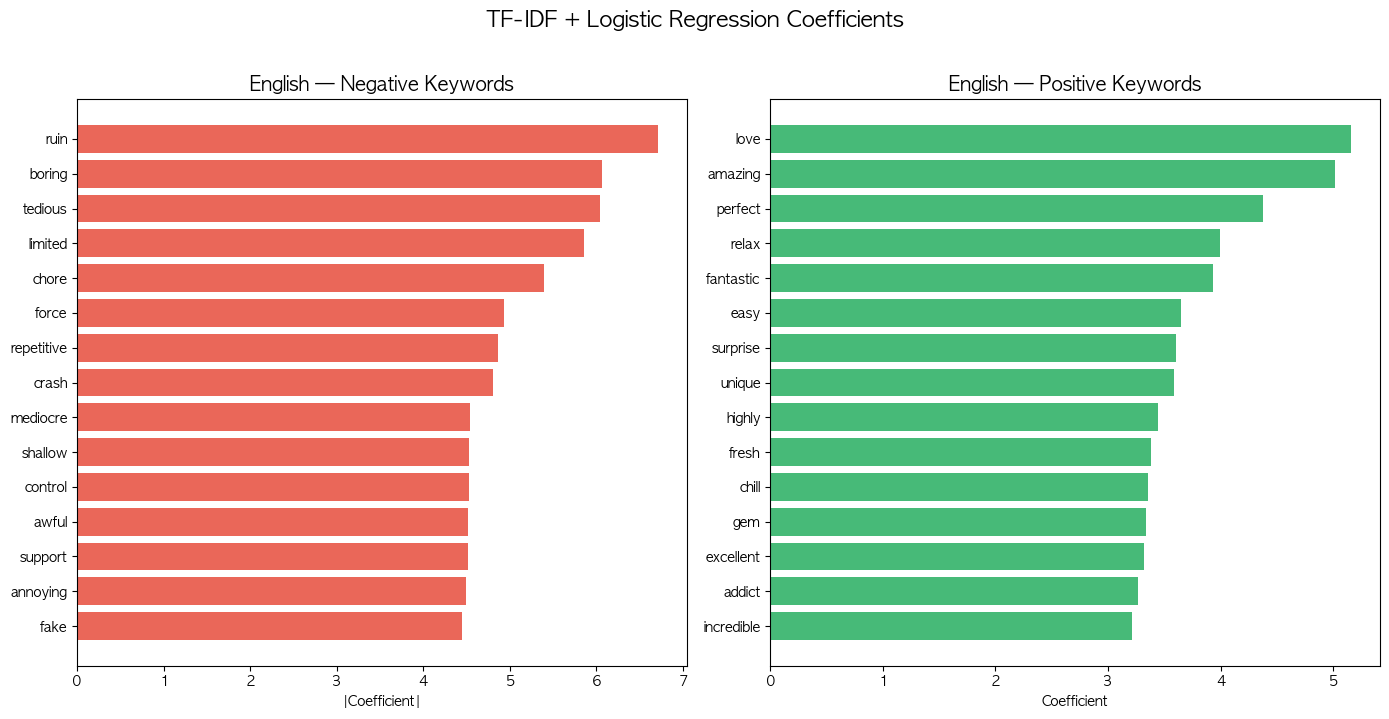

 저장: reports/figures/keywords_en.png


In [ ]:
# ── 영어 키워드 시각화 ──
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

n_show = 15

# 부정
words = [w for w, s in neg_kw_en[:n_show]]
scores = [abs(s) for w, s in neg_kw_en[:n_show]]
axes[0].barh(words[::-1], scores[::-1], color='#E74C3C', alpha=0.85)
axes[0].set_title('English — Negative Keywords', fontsize=14, fontweight='bold')
axes[0].set_xlabel('|Coefficient|')

# 긍정
words = [w for w, s in pos_kw_en[:n_show]]
scores = [s for w, s in pos_kw_en[:n_show]]
axes[1].barh(words[::-1], scores[::-1], color='#27AE60', alpha=0.85)
axes[1].set_title('English — Positive Keywords', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Coefficient')

plt.suptitle('TF-IDF + Logistic Regression Coefficients', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('../reports/figures/keywords_en.png', dpi=150, bbox_inches='tight')
plt.show()
print(' 저장: reports/figures/keywords_en.png')

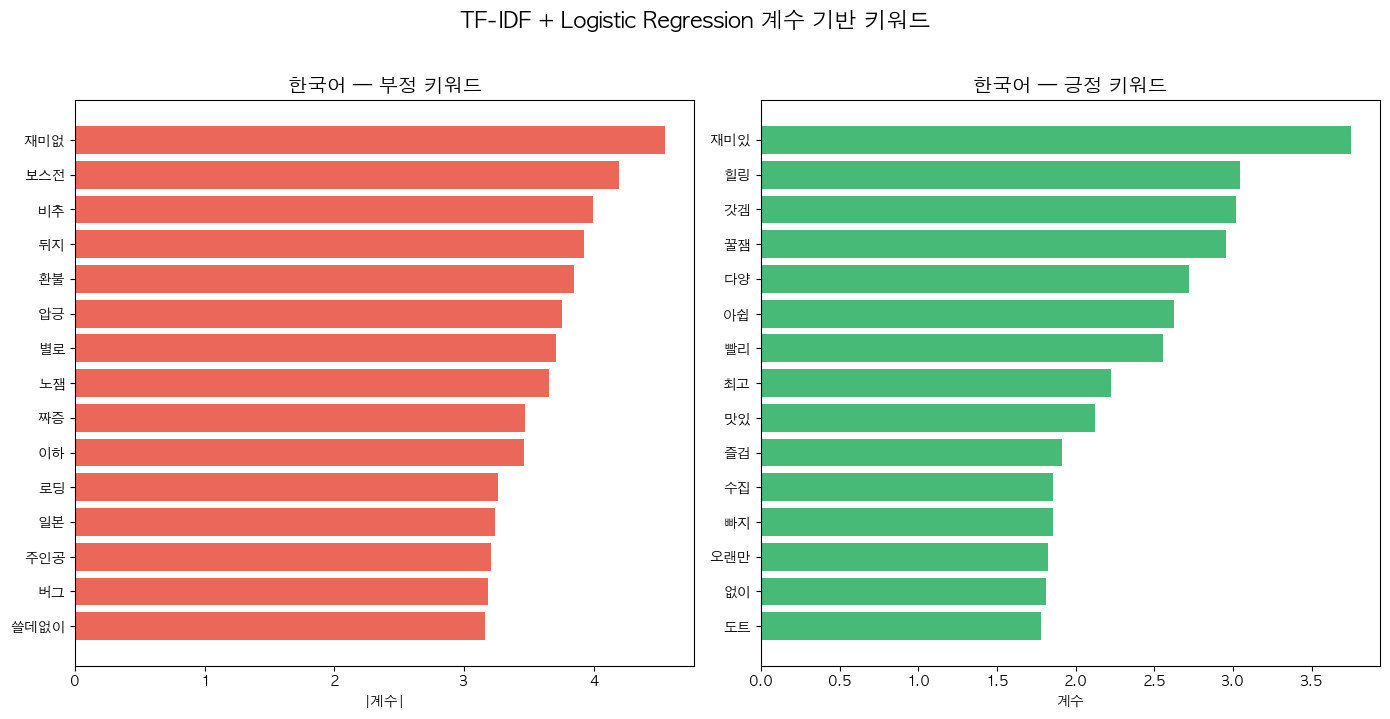

저장: reports/figures/keywords_ko.png


In [14]:
# ── 한국어 키워드 시각화 ──
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# 부정
words = [w for w, s in neg_kw_ko[:n_show]]
scores = [abs(s) for w, s in neg_kw_ko[:n_show]]
axes[0].barh(words[::-1], scores[::-1], color='#E74C3C', alpha=0.85)
axes[0].set_title('한국어 — 부정 키워드', fontsize=14, fontweight='bold')
axes[0].set_xlabel('|계수|')

# 긍정
words = [w for w, s in pos_kw_ko[:n_show]]
scores = [s for w, s in pos_kw_ko[:n_show]]
axes[1].barh(words[::-1], scores[::-1], color='#27AE60', alpha=0.85)
axes[1].set_title('한국어 — 긍정 키워드', fontsize=14, fontweight='bold')
axes[1].set_xlabel('계수')

plt.suptitle('TF-IDF + Logistic Regression 계수 기반 키워드', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('../reports/figures/keywords_ko.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장: reports/figures/keywords_ko.png')

---
## 7. 결과 저장

In [15]:
# ── 모델 성능 요약 저장 ──
summary = pd.DataFrame([
    {
        'language': 'english',
        'model': 'LogReg_TF-IDF',
        'n_train': X_train_en.shape[0],
        'n_test': X_test_en.shape[0],
        'accuracy': round(accuracy_score(y_test_en, model_en.predict(X_test_en)), 4),
        'f1_macro': round(f1_score(y_test_en, model_en.predict(X_test_en), average='macro'), 4),
    },
    {
        'language': 'korean',
        'model': 'LogReg_TF-IDF',
        'n_train': X_train_ko.shape[0],
        'n_test': X_test_ko.shape[0],
        'accuracy': round(accuracy_score(y_test_ko, model_ko.predict(X_test_ko)), 4),
        'f1_macro': round(f1_score(y_test_ko, model_ko.predict(X_test_ko), average='macro'), 4),
    }
])
summary.to_sql('sentiment_model_summary', conn, if_exists='replace', index=False)

# ── 키워드 저장 ──
kw_rows = []
for word, score in pos_kw_en:
    kw_rows.append({'language': 'english', 'sentiment': 'positive', 'keyword': word, 'coefficient': score})
for word, score in neg_kw_en:
    kw_rows.append({'language': 'english', 'sentiment': 'negative', 'keyword': word, 'coefficient': score})
for word, score in pos_kw_ko:
    kw_rows.append({'language': 'korean', 'sentiment': 'positive', 'keyword': word, 'coefficient': score})
for word, score in neg_kw_ko:
    kw_rows.append({'language': 'korean', 'sentiment': 'negative', 'keyword': word, 'coefficient': score})

kw_df = pd.DataFrame(kw_rows)
kw_df.to_sql('sentiment_keywords', conn, if_exists='replace', index=False)

print(' DB 저장 완료')
print(f'  - sentiment_model_summary: {len(summary)}건')
print(f'  - sentiment_keywords: {len(kw_df)}건')
print()
print(summary.to_string(index=False))

 DB 저장 완료
  - sentiment_model_summary: 2건
  - sentiment_keywords: 80건

language         model  n_train  n_test  accuracy  f1_macro
 english LogReg_TF-IDF    35871    8968    0.9351    0.7172
  korean LogReg_TF-IDF     8059    2015    0.9315    0.6029


---
## 8. DB 연결 종료

In [16]:
conn.close()
print('DB 연결 종료')

DB 연결 종료
